### SQL Database Schema Documentation

#### Table: `tests`
This table stores metadata tracking each unique test run

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`test_id`** | INTEGER | Unix timestamp of when the test was run|
| **`dut`** | INTEGER | Device Under Test (currently slot on the test rig) |
| **`test_name`** | TEXT | String representation of test (currently meaningless) |
| **`test_type_id`** | INTEGER | Used for identifying different types of tests |

---

#### Table: `readings`
This table captures the time-series measurement streams linked to a specific test execution.

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`test_id`** | INTEGER | Foreign key referencing `tests(test_id)` |
| **`TARGET`** | INTEGER | Target flow rate setpoint value |
| **`FLOW`** | REAL | Measured flow rate |
| **`UP`** | REAL | Upstream raw measurement value |
| **`DOWN`** | REAL | Downstream raw measurement value |
| **`AMB`** | REAL | Ambient background |
| **`SYS`** | INTEGER | System-level diagnostic parameter or supply voltage |
| **`t`** | REAL | Elapsed time (mV) calculated from starting SYS value |
| **`DELTA`** | REAL | Calculated differential voltage ($\Delta = \text{UP} - \text{DOWN}$) |
| **`UP_N`** | REAL | Normalized Upstream value |
| **`DOWN_N`** | REAL | Normalized Downstream value |
| **`AMB_N`** | REAL | Normalized Ambient reference |
| **`DELTA_N`** | REAL | Normalized differential value ($\Delta_N$) |

In [ ]:
import pandas as pd
import numpy as np
import sqlite3

"""Class to represent the test database being accessed 

Offers access methods to convert test runs and access data from specific duts

Attributes:
    db_name: raw name of database in same directory without extensions
"""
class Database():

    def __init__(self, db_name):
        self.conn = sqlite3.connect(f'{db_name}')
        self.cur = self.conn.cursor()
        self.cur.execute('SELECT * FROM \'tests\'')
        self.reading_columns = []
        for col in self.cur.execute('PRAGMA table_info(readings)').fetchall():
            self.reading_columns.append(col[1])
        pass

    """Function to flush pending writes and release any write restritcions

    SQLite3 connections by default lock the file that is being used, this releases it from the notebook's possession

    """
    def release_file(self):
        self.conn.commit()
        self.cur.close()
        self.conn.close()

    # PRIVATE METHODS

    """Grabs all test ids from a specific dut
    """
    def _get_test_ids(self,dut : int):
        return [id[0] for id in self.cur.execute('SELECT test_id FROM \'tests\' where dut=?',(dut,)).fetchall()]
    
    """Returns a dataframe containing the full test data for one run 
    
    Attributes:
        test_id: test id (unix timestamp) to grab data
    """
    def _test_from_sql(self,test_id):
        sql_result = self.cur.execute('SELECT * FROM \'readings\' where test_id LIKE ?',(test_id,)).fetchall()
        return pd.DataFrame(sql_result, columns=self.reading_columns)
    
    """Returns a dataframe containing the full test data for one run 
    
    Attributes:
        test_id: test id (unix timestamp) to grab data
    """
    def _extract_run_from_sql(self,test_id):
        return self.cur.execute('SELECT * FROM \'readings\' where test_id LIKE ?',(test_id,)).fetchall()
    

    def get_tests(self,dut):
        return [self._test_from_sql(id) for id in self._get_test_ids(dut)]

    def get_lifetime_dut_readings(self,dut :int):
        return pd.DataFrame(self.cur.execute('SELECT * FROM \'readings\' WHERE test_id IN ( \
                            SELECT test_id FROM \'tests\' WHERE dut=? \
                        )', (dut,)).fetchall(),columns=self.reading_columns)
    def get_all_data(self):
        return pd.DataFrame(self.cur.execute('SELECT * FROM \'readings\'').fetchall(),columns=self.reading_columns)
    
    def execute_custom_cmd(self,cmd):
        return self.cur.execute(cmd)

class Helper:

    def filter_by_flow(data, min_flow):
        return data[data['FLOW'] > min_flow]
    
    def filter_by_data_time(data, time_start):
        return data[(data['test_id'] > time_start)]
    

d = Database('C:/Users/sennm/Downloads/FlowMeterTestRigBR/FLowMeterTestRig/python/pi-dev/pi_test.db')

dut_data = [d.get_lifetime_dut_readings(i) for i in range(0,5)]
full_data = d.get_all_data()
d.release_file()



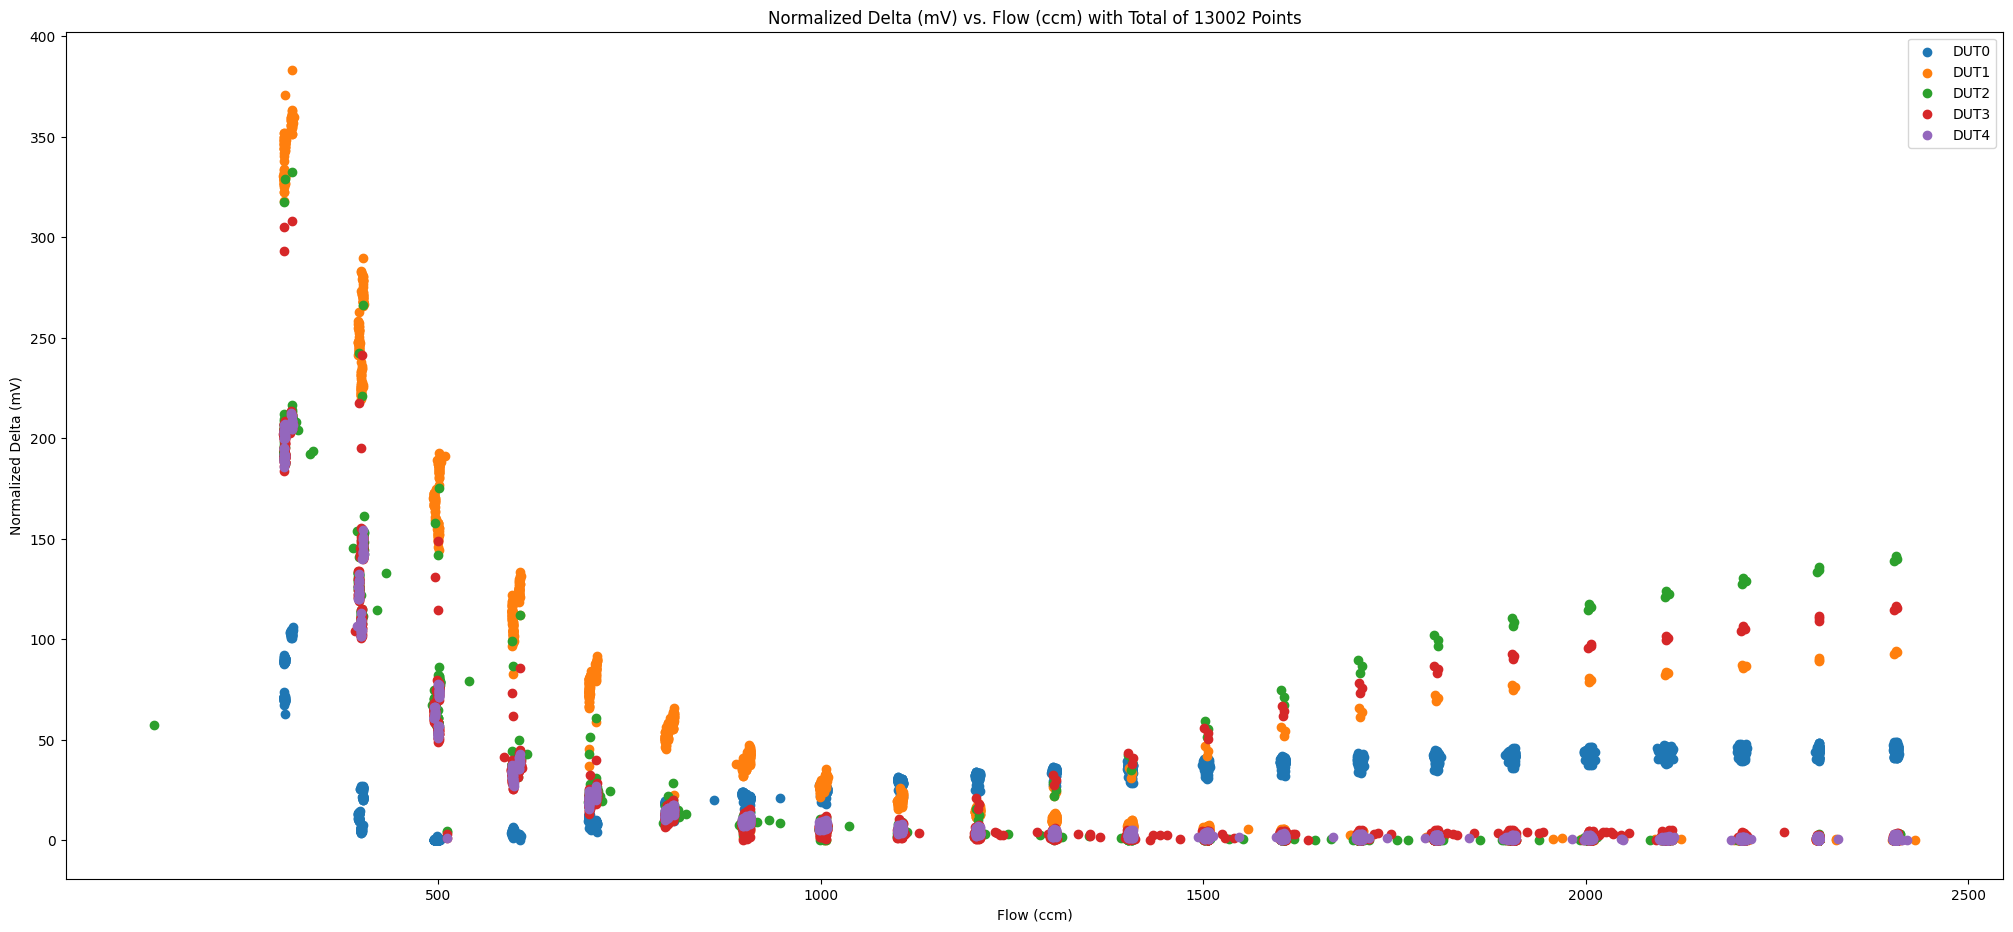

In [82]:
import matplotlib.pyplot as plt



plt.figure(figsize=(25,11))
for i in range(0,5):
    data = dut_data[i]
    filtered = Helper.filter_by_flow(data,500)
    #1782155408
    filtered = Helper.filter_by_data_time(data,1782160626)
    # print(pd.cut(filtered['FLOW'],range(0,2500,100)))
    plt.scatter(filtered['FLOW'], filtered['DELTA_N']*1000,label=f'DUT{i}')
plt.xlabel('Flow (ccm)')
plt.ylabel('Normalized Delta (mV)')
plt.title(f'Normalized Delta (mV) vs. Flow (ccm) with Total of {len(full_data)} Points')
plt.legend()

In [68]:
import pandas as pd
from scipy import stats
import statistics
import numpy as np

for i in range(0,5):
    data = dut_data[i]

    filtered = Helper.filter_by_flow(data,500)
    # filtered = Helper.filter_by_data_time(data,1782155408)

    filtered['bins'] = pd.cut(filtered['FLOW'],bins= 22)
    # plt.hist(filtered['bins'],bins=4)
    filtered.bins.value_counts()
    std_dev_list = filtered.groupby('bins',observed=False)['FLOW'].std(ddof=1)
    
    print(f'Standard deviation in Delta at All Flow Rates: σ (range) = [{min(std_dev_list):.3f},{max(std_dev_list):.3f}][mV] with x̄ = {np.nanmean(std_dev_list):.3f} [mV]')


Standard deviation in Delta at All Flow Rates: σ (range) = [0.399,16.851][mV] with x̄ = 3.891 [mV]
Standard deviation in Delta at All Flow Rates: σ (range) = [0.141,10.371][mV] with x̄ = 3.416 [mV]
Standard deviation in Delta at All Flow Rates: σ (range) = [0.997,19.393][mV] with x̄ = 5.282 [mV]
Standard deviation in Delta at All Flow Rates: σ (range) = [2.107,25.967][mV] with x̄ = 6.946 [mV]
Standard deviation in Delta at All Flow Rates: σ (range) = [1.828,38.325][mV] with x̄ = 6.297 [mV]


C:\Users\sennm\AppData\Local\Temp\ipykernel_19892\2506756440.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['bins'] = pd.cut(filtered['FLOW'],bins= 22)
C:\Users\sennm\AppData\Local\Temp\ipykernel_19892\2506756440.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['bins'] = pd.cut(filtered['FLOW'],bins= 22)
C:\Users\sennm\AppData\Local\Temp\ipykernel_19892\2506756440.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [81]:
import pandas as pd
from scipy import stats
import statistics
import numpy as np

filtered = Helper.filter_by_flow(full_data,500)
filtered = Helper.filter_by_data_time(data,1782155408)

filtered['bins'] = pd.cut(filtered['FLOW'],bins= 22)
# plt.hist(filtered['bins'],bins=4)
filtered.bins.value_counts()
std_dev_list = filtered.groupby('bins',observed=False)['FLOW'].std()

max_deviation = max(std_dev_list)
min_deviation = min(std_dev_list)
avg_deviation = np.nanmean(std_dev_list)

print(f'Standard deviation in Delta at All Flow Rates: σ (range) = [{min_deviation:.3f},{max_deviation:.3f}][mV] with x̄ = {avg_deviation:.3f} [mV]')





Standard deviation in Delta at All Flow Rates: σ (range) = [1.013,14.557][mV] with x̄ = 5.076 [mV]


# Lookup Table Brute Force Attempt

## Approach
This section will attempt to take the average of 5 runs and apply it to another dataset. Firstly, it will apply on an intra-meter basis. Then to evaluate variability, it will be applied to another meter. This is simple math and is not expected to completely function. 
